In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [9]:
root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_test')]

In [5]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

In [10]:
scenario_name = "ex_con_2025_full_test"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [11]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0',  'root_area_index', 'wcont_sigma_deviation','g_bark', 'vmax25' , 'jmax25']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [12]:
post_path

'/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_test/post'

In [14]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
df_grp = df.groupby(['id'])[vars].mean()

In [15]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,vmax25,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
1358,3,1441,271,1800.0,1800,False,1.0,4.0,Weibull,49.027076,...,4.397672,8.822853,4.597108,4.866062,4.588747,4.536209,5.255526,0.958607,0.987948,3
1357,2,4102,271,1800.0,1800,False,1.0,4.0,Weibull,39.078260,...,1.614655,1.726269,0.938800,1.074210,0.923310,0.865784,1.088907,0.958607,0.987948,2
1359,4,4436,271,1800.0,1800,False,1.0,4.0,Weibull,40.619437,...,4.255351,7.415441,3.895508,4.146595,3.884873,3.827425,4.450178,0.958607,0.987948,4
1356,1,200,271,1800.0,1800,False,1.0,4.0,Weibull,45.710428,...,2.908651,3.121662,1.794366,1.969669,1.769011,1.726245,2.027106,0.958607,0.987948,1
1355,0,5802,271,1800.0,1800,False,1.0,4.0,Weibull,40.714363,...,0.401616,0.313225,0.450638,0.431571,0.520069,0.419484,0.439086,0.958607,0.987948,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3718,3,2367,743,1800.0,1800,False,1.0,4.0,Weibull,31.327059,...,3.316361,3.538652,2.059738,2.248053,2.026071,1.993561,2.314806,0.973711,1.099943,3
3719,4,725,743,1800.0,1800,False,1.0,4.0,Weibull,29.457522,...,17.278950,17.466307,10.592320,11.099937,10.568577,10.552654,11.662360,0.973711,1.099943,4
3717,2,5038,743,1800.0,1800,False,1.0,4.0,Weibull,25.925615,...,1.601362,1.709811,0.968452,1.114002,0.945386,0.896858,1.115276,0.973711,1.099943,2
3716,1,2367,743,1800.0,1800,False,1.0,4.0,Weibull,31.327059,...,3.316361,3.538652,2.059738,2.248053,2.026071,1.993561,2.314806,0.973711,1.099943,1


In [16]:
df.loc[df['sid'] == 3,'sid']= 4
df.loc[df['sid'] == 2,'sid']= 3
df['sid']

1358    4
1357    3
1359    4
1356    1
1355    0
       ..
3718    4
3719    4
3717    3
3716    1
3715    0
Name: sid, Length: 810, dtype: int64

In [17]:
dead_ids =[0,3,6,7]
dfs =df[df['sid'] == 0]
dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
dfs.to_csv(os.path.join(post_path, "Alive.csv"))
for i in range(1,5):
    dfs =df[df['sid'] == i]
    dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)
    dfs.to_csv(os.path.join(post_path, f"Dead{i}.csv"))

/tmp/ipykernel_3681111/984454782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
/tmp/ipykernel_3681111/984454782.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)


In [18]:
for var in vars:
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    ax.hist(df_grp[var], alpha=1.0, bins = 20)
    ax.set_xlabel(var)
    plt.savefig(f"{post_path}/mean_hist_{var}.png")
    plt.close(fig)

In [21]:
dv = df[vars]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/tmp/ipykernel_3681111/3013431960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [22]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,vmax25,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
1358,3,1441,271,1800.0,1800,False,1.0,4.0,Weibull,49.027076,...,4.397672,8.822853,4.597108,4.866062,4.588747,4.536209,5.255526,0.958607,0.987948,4
1357,2,4102,271,1800.0,1800,False,1.0,4.0,Weibull,39.078260,...,1.614655,1.726269,0.938800,1.074210,0.923310,0.865784,1.088907,0.958607,0.987948,3
1359,4,4436,271,1800.0,1800,False,1.0,4.0,Weibull,40.619437,...,4.255351,7.415441,3.895508,4.146595,3.884873,3.827425,4.450178,0.958607,0.987948,4
1356,1,200,271,1800.0,1800,False,1.0,4.0,Weibull,45.710428,...,2.908651,3.121662,1.794366,1.969669,1.769011,1.726245,2.027106,0.958607,0.987948,1
1355,0,5802,271,1800.0,1800,False,1.0,4.0,Weibull,40.714363,...,0.401616,0.313225,0.450638,0.431571,0.520069,0.419484,0.439086,0.958607,0.987948,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3718,3,2367,743,1800.0,1800,False,1.0,4.0,Weibull,31.327059,...,3.316361,3.538652,2.059738,2.248053,2.026071,1.993561,2.314806,0.973711,1.099943,4
3719,4,725,743,1800.0,1800,False,1.0,4.0,Weibull,29.457522,...,17.278950,17.466307,10.592320,11.099937,10.568577,10.552654,11.662360,0.973711,1.099943,4
3717,2,5038,743,1800.0,1800,False,1.0,4.0,Weibull,25.925615,...,1.601362,1.709811,0.968452,1.114002,0.945386,0.896858,1.115276,0.973711,1.099943,3
3716,1,2367,743,1800.0,1800,False,1.0,4.0,Weibull,31.327059,...,3.316361,3.538652,2.059738,2.248053,2.026071,1.993561,2.314806,0.973711,1.099943,1


In [21]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark,sid
2819,-0.011716,1.048244,-1.180484,-0.691793,-0.614963,-1.209907,1.012856,-0.382971,0.453594,-0.981078,0.035330,-0.997436,-0.449610,-0.929715,0.476267,-0.792508,-0.733916,4
2818,-0.848153,1.790065,0.059491,-1.235485,-0.832144,-1.594270,1.228173,-0.594581,1.127885,0.942604,0.083758,-0.165071,-1.170499,-1.011457,-0.053609,-0.613764,-0.917141,3
2817,0.744504,0.735909,0.877077,-0.765570,-1.081380,-1.371938,-1.933288,-0.409570,-0.893392,0.255775,1.610266,-0.815696,0.525152,-1.324449,0.087068,-0.936773,-1.065603,1
2816,-0.468073,1.671534,-0.909701,-1.293406,-1.216632,-1.253290,-1.001933,-1.112874,1.204380,0.681584,0.894730,0.466909,-1.016902,-1.074428,0.637134,1.880437,-0.659082,0
42613,0.666928,1.150280,0.856485,-0.127219,-0.929483,-1.356427,1.218943,-1.334891,0.516275,-0.137375,1.811623,-1.003968,-0.299243,-0.397558,0.425452,-0.857342,-1.013115,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37800,0.162835,0.361908,0.235148,1.053373,-0.536359,0.040134,-2.019117,1.381945,0.276948,-0.783658,0.505329,2.140311,1.844545,-0.698695,1.710293,1.321035,1.645325,0
5729,0.781662,0.054731,-0.309391,1.193842,-0.875875,-0.796525,0.869574,-0.783178,-2.166829,-1.136331,1.054649,-0.291190,1.273981,1.273885,-1.367766,-0.616274,-1.172729,1
5730,0.781662,0.054731,-0.309391,1.193842,-0.875875,-0.796525,0.869574,-0.783178,-2.166829,-1.136331,1.054649,-0.291190,1.273981,1.273885,-1.367766,-0.616274,-1.172729,3
5728,-0.103815,0.242240,-1.110656,0.913212,-1.112863,-1.094303,-0.182244,-0.402421,-1.162797,1.889230,1.050412,1.238847,-0.717961,1.258261,-0.500280,1.318302,-1.277828,0


ValueError: operands could not be broadcast together with shapes (324,) (162,) 

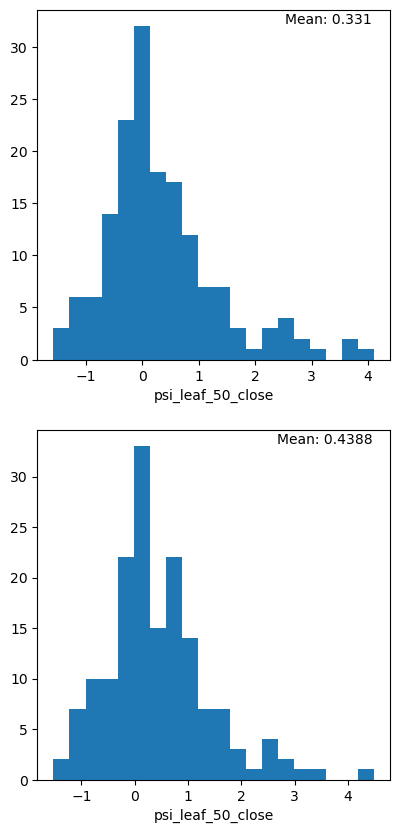

In [23]:
for var in vars:
   #if (var == 'id') | (var == 'sid'):
   #     continue        
    fig = plt.figure(figsize=(10,10))
    for sid in [1,3,4]:
        dfh = pd.DataFrame()
        dfh[var] = df_norm[df_norm['sid'] == sid][var].values - df_norm[df_norm['sid'] == 0][var].values
        ax = fig.add_subplot(2,2,sid)
        ax.hist(dfh[var], alpha=1.0, bins = 20)
        ax.set_xlabel(var)
        ax.text(0.95, 0.95, f"Mean: {np.round(dfh[var].mean(), 4)}",
        verticalalignment ='bottom',
        horizontalalignment ='right',
        transform = ax.transAxes)
    plt.savefig(f"{post_path}/sid_hist_{var}.png")
    plt.close(fig)